In [168]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import plot_tree
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, skew

In [142]:
path = r"C:\Users\13926\Atlantic-Project\AmesHousingClean.csv"
df = pd.read_csv(path)

In [143]:
X = df.drop(columns=['SalePrice', 'Neighborhood'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [144]:
# Encode 'Neighborhood' by the average sale price in each neighborhood
# Encoding 'Neighborhood' is temporarily abandoned
"""
neighborhood_avg = X_train.join(y_train).groupby('Neighborhood')['SalePrice'].mean()
X_train['Neighborhood_encoded'] = X_train['Neighborhood'].map(neighborhood_avg)
X_test['Neighborhood_encoded'] = X_test['Neighborhood'].map(neighborhood_avg)
X_test['Neighborhood_encoded'] = X_test['Neighborhood_encoded'].fillna(neighborhood_avg.mean())
X_train.drop(columns='Neighborhood', inplace=True)
X_test.drop(columns='Neighborhood', inplace=True)
"""

"\nneighborhood_avg = X_train.join(y_train).groupby('Neighborhood')['SalePrice'].mean()\nX_train['Neighborhood_encoded'] = X_train['Neighborhood'].map(neighborhood_avg)\nX_test['Neighborhood_encoded'] = X_test['Neighborhood'].map(neighborhood_avg)\nX_test['Neighborhood_encoded'] = X_test['Neighborhood_encoded'].fillna(neighborhood_avg.mean())\nX_train.drop(columns='Neighborhood', inplace=True)\nX_test.drop(columns='Neighborhood', inplace=True)\n"

In [ ]:
def get_iqr_bounds(series, multiplier=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    return lower, upper

num_cols = X.select_dtypes(include='number').columns.tolist()
for col in num_cols:
    lower, upper = get_iqr_bounds(X_train[col])
    n_outliers = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    print(f'{col}: bounds=({lower:.2f}, {upper:.2f}), outliers={n_outliers} ({n_outliers/len(X_train)*100:.1f}%)')


# Cap outliers
cols_to_check = num_cols
def cap_outliers(X, columns, multiplier=1.5):
    X = X.copy()
    for col in columns:
        lower, upper = get_iqr_bounds(X[col], multiplier)
        X[col] = X[col].clip(lower, upper)
    return X

X_train_capped = cap_outliers(X_train, cols_to_check)
X_test_capped = cap_outliers(X_test, cols_to_check)

In [ ]:
# Scale using Standard Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_capped)
X_test_scaled = scaler.transform(X_test_capped)

In [146]:
# Fit the data to Linear Regression and see the result
lin_regressor = LinearRegression()
lin_regressor.fit(X_train_scaled, y_train)
y_train_pred_lin = lin_regressor.predict(X_train_scaled)
y_pred_lin = lin_regressor.predict(X_test_scaled)

mae_train_lin = mean_absolute_error(y_train, y_train_pred_lin)
mae_test_lin = mean_absolute_error(y_test, y_pred_lin)
mape_train_lin = mean_absolute_percentage_error(y_train, y_train_pred_lin) * 100
mape_test_lin = mean_absolute_percentage_error(y_test, y_pred_lin) * 100
r2_train_lin = r2_score(y_train, y_train_pred_lin)
r2_test_lin = r2_score(y_test, y_pred_lin)

print(f'MAE (training): {mae_train_lin}')
print(f'MAE (testing): {mae_test_lin}')
print(f'MAPE (training): {mape_train_lin:.4f}%')
print(f'MAPE (testing): {mape_test_lin:.4f}%')
print(f'R-Squared score (training): {r2_train_lin}')
print(f'R-Squared score (testing): {r2_test_lin}')

MAE (training): 23516.761340961348
MAE (testing): 22597.888651041307
MAPE (training): 13.5300%
MAPE (testing): 12.8434%
R-Squared score (training): 0.7922998199813032
R-Squared score (testing): 0.8194873194358329


In [147]:
# Fit with KNN Regressor
knn_regressor = KNeighborsRegressor()
knn_regressor.fit(X_train_scaled, y_train)
y_train_pred_knn = knn_regressor.predict(X_train_scaled)
y_pred_knn = knn_regressor.predict(X_test_scaled)

mae_test_knn_default = mean_absolute_error(y_test, y_pred_knn)
mape_test_knn_default = mean_absolute_percentage_error(y_test, y_pred_knn) * 100
r2_train_knn_default = r2_score(y_train, y_train_pred_knn)
r2_test_knn_default = r2_score(y_test, y_pred_knn)

print(f'MAE (testing): {mae_test_knn_default}')
print(f'MAPE (testing): {mape_test_knn_default:.4f}%')
print(f'R-Squared score (training): {r2_train_knn_default}')
print(f'R-Squared score (testing): {r2_test_knn_default}')

MAE (testing): 20080.605555555554
MAPE (testing): 11.3524%
R-Squared score (training): 0.9003025321991948
R-Squared score (testing): 0.8498950853524728


In [148]:
# Fine-tune KNN Regressor with grid search
param_grid_knn = {'n_neighbors': range(1, 31, 2),
                  'weights': ['uniform', 'distance'],
                  'metric': ['euclidean', 'manhattan', 'minkowski'], }
grid_knn = GridSearchCV(KNeighborsRegressor(), param_grid_knn, cv=5, scoring='neg_mean_absolute_error', n_jobs=-2)
grid_knn.fit(X_train_scaled, y_train)
print(grid_knn.best_params_)

{'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}


In [149]:
# Fit the fine-tuned KNN Regressor
knn_regressor = KNeighborsRegressor(**grid_knn.best_params_)
knn_regressor.fit(X_train_scaled, y_train)
y_train_pred_knn = knn_regressor.predict(X_train_scaled)
y_pred_knn = knn_regressor.predict(X_test_scaled)

mae_train_knn_best = mean_absolute_error(y_train, y_train_pred_knn)
mae_test_knn_best = mean_absolute_error(y_test, y_pred_knn)
mape_train_knn_best = mean_absolute_percentage_error(y_train, y_train_pred_knn) * 100
mape_test_knn_best = mean_absolute_percentage_error(y_test, y_pred_knn) * 100
r2_train_knn_best = r2_score(y_train, y_train_pred_knn)
r2_test_knn_best = r2_score(y_test, y_pred_knn)

print(f'MAE (training): {mae_train_knn_best}')
print(f'MAE (testing): {mae_test_knn_best}')
print(f'MAPE (training): {mape_train_knn_best:.4f}%')
print(f'MAPE (testing): {mape_test_knn_best:.4f}%')
print(f'R-Squared score (training): {r2_train_knn_best}')
print(f'R-Squared score (testing): {r2_test_knn_best}')

MAE (training): 48.74907407407407
MAE (testing): 18952.85366930951
MAPE (training): 0.0328%
MAPE (testing): 10.4620%
R-Squared score (training): 0.9999534711920957
R-Squared score (testing): 0.8519586420191667


In [150]:
# Try with Random Forest Regressor
rf_regressor = RandomForestRegressor()
rf_regressor.fit(X_train_scaled, y_train)
y_train_pred_rf = rf_regressor.predict(X_train_scaled)
y_pred_rf = rf_regressor.predict(X_test_scaled)

mae_test_rf_default = mean_absolute_error(y_test, y_pred_rf)
mape_test_rf_default = mean_absolute_percentage_error(y_test, y_pred_rf) * 100
r2_train_rf_default = r2_score(y_train, y_train_pred_rf)
r2_test_rf_default = r2_score(y_test, y_pred_rf)

print(f'MAE (testing): {mae_test_rf_default}')
print(f'MAPE (testing): {mape_test_rf_default:.4f}%')
print(f'R-Squared score (training): {r2_train_rf_default}')
print(f'R-Squared score (testing): {r2_test_rf_default}')

MAE (testing): 17536.44957557319
MAPE (testing): 10.0379%
R-Squared score (training): 0.984318671176343
R-Squared score (testing): 0.8745804713796077


In [151]:
# Also do grid search on Random Forest Regressor
"""
param_grid = {
    'n_estimators': [np.random.randint(100, 300), np.random.randint(100, 300)],
    'max_features': ['sqrt', 'auto'],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
}

grid_rf = GridSearchCV(RandomForestRegressor(), param_grid=param_grid, scoring='neg_mean_absolute_error', cv=5)
grid_rf.fit(X_train_scaled, y_train)
print('Best Parameters', grid_rf.best_params_)
"""

"\nparam_grid = {\n    'n_estimators': [np.random.randint(100, 300), np.random.randint(100, 300)],\n    'max_features': ['sqrt', 'auto'],\n    'max_depth': [10, 20, 30, None],\n    'min_samples_leaf': [1, 2, 4],\n    'min_samples_split': [2, 5, 10],\n}\n\ngrid_rf = GridSearchCV(RandomForestRegressor(), param_grid=param_grid, scoring='neg_mean_absolute_error', cv=5)\ngrid_rf.fit(X_train_scaled, y_train)\nprint('Best Parameters', grid_rf.best_params_)\n"

In [152]:
# print('Best Parameters', grid_rf.best_params_)

In [153]:
"""
n_estimators=215,
                                     max_depth=9,
                                     max_features='sqrt',
                                     min_samples_leaf=1,
                                     min_samples_split=2,

"""

"\nn_estimators=215,\n                                     max_depth=9,\n                                     max_features='sqrt',\n                                     min_samples_leaf=1,\n                                     min_samples_split=2,\n\n"

In [154]:
# Fit the fine-tuned model
rf_regressor_tuned = RandomForestRegressor(n_estimators=201,
                                           max_depth=9,
                                           max_features='sqrt',
                                           min_samples_leaf=1,
                                           min_samples_split=2,)
rf_regressor_tuned.fit(X_train_scaled, y_train)
y_train_pred_rf_tuned = rf_regressor_tuned.predict(X_train_scaled)
y_pred_rf_tuned = rf_regressor_tuned.predict(X_test_scaled)

mae_train_rf_tuned = mean_absolute_error(y_train, y_train_pred_rf_tuned)
mae_test_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
mape_train_rf_tuned = mean_absolute_percentage_error(y_train, y_train_pred_rf_tuned) * 100
mape_test_rf_tuned = mean_absolute_percentage_error(y_test, y_pred_rf_tuned) * 100
r2_train_rf_tuned = r2_score(y_train, y_train_pred_rf_tuned)
r2_test_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print(f'MAE (training): {mae_train_rf_tuned}')
print(f'MAE (testing): {mae_test_rf_tuned}')
print(f'MAPE (training): {mape_train_rf_tuned:.4f}%')
print(f'MAPE (testing): {mape_test_rf_tuned:.4f}%')
print(f'R-Squared score (training): {r2_train_rf_tuned}')
print(f'R-Squared score (testing): {r2_test_rf_tuned}')

MAE (training): 11913.707922324824
MAE (testing): 16887.00023469018
MAPE (training): 7.0987%
MAPE (testing): 9.7064%
R-Squared score (training): 0.9570528474503878
R-Squared score (testing): 0.8821051175888521


In [175]:
print(root_mean_squared_error(y_test, y_pred_rf))

27274.30885663959


In [155]:
print(root_mean_squared_error(y_test, y_pred_rf_tuned))
df_y_pred_rf_tuned = pd.DataFrame(y_pred_rf_tuned, columns=['PredictedPrice'])
df_y_test = pd.DataFrame(y_test).reset_index(drop=True)
df_eval = pd.concat([df_y_pred_rf_tuned, df_y_test], axis=1)
df_eval['AbsoluteError'] = abs(df_eval['SalePrice'] - df_eval['PredictedPrice'])
df_eval.sort_values(by='AbsoluteError', ascending=False).head(10)


26443.482468885242


,PredictedPrice,SalePrice,AbsoluteError
473,372563.207627,150000.0,222563.207627
185,432906.988281,611657.0,178750.011719
303,442729.919516,556581.0,113851.080484
32,264578.674719,375000.0,110421.325281
238,206842.815507,311500.0,104657.184493
279,245547.268732,328000.0,82452.731268
379,253332.857103,335000.0,81667.142897
155,453692.974060,535000.0,81307.025940
413,315213.232979,395000.0,79786.767021
22,212658.536407,133900.0,78758.536407


In [156]:
df_eval.sort_values(by='SalePrice', ascending=False).head(10)

,PredictedPrice,SalePrice,AbsoluteError
185,432906.988281,611657.0,178750.011719
303,442729.919516,556581.0,113851.080484
155,453692.974060,535000.0,81307.025940
204,480829.121155,500000.0,19170.878845
44,468787.307314,485000.0,16212.692686
424,418583.315929,475000.0,56416.684071
316,394123.071682,470000.0,75876.928318
80,419701.620697,460000.0,40298.379303
250,410647.073977,451950.0,41302.926023
162,400776.686525,419005.0,18228.313475


Distribution Mean: 186831, Skew: 1.7901 and Std Deviation: 79546


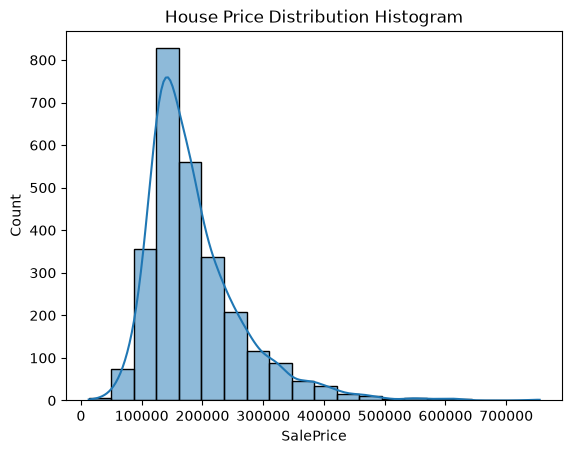

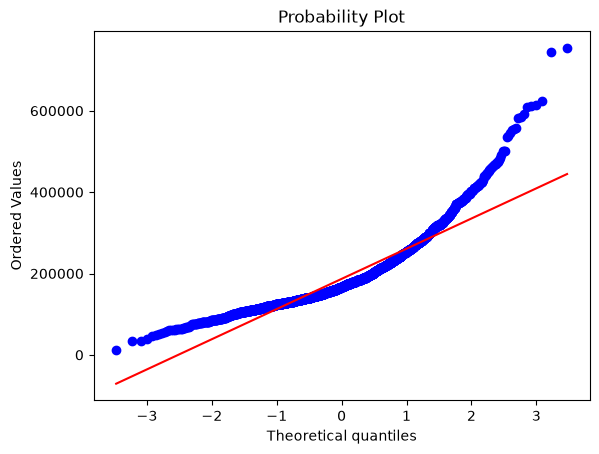

In [170]:
sns.histplot(df['SalePrice'], bins=20, kde=True)

(mu, sigma) = norm.fit(df['SalePrice'])
print(f'Distribution Mean: {mu.astype(int)}, Skew: {df.SalePrice.skew():.5} and Std Deviation: {sigma.astype(int)}')

plt.title('House Price Distribution Histogram')
fig = plt.figure()
res = stats.probplot(df['SalePrice'], plot=plt)
plt.show()

Distribution Mean: 12.061536568129855, Skew: 0.17603 and Std Deviation: 0.38440993467589724


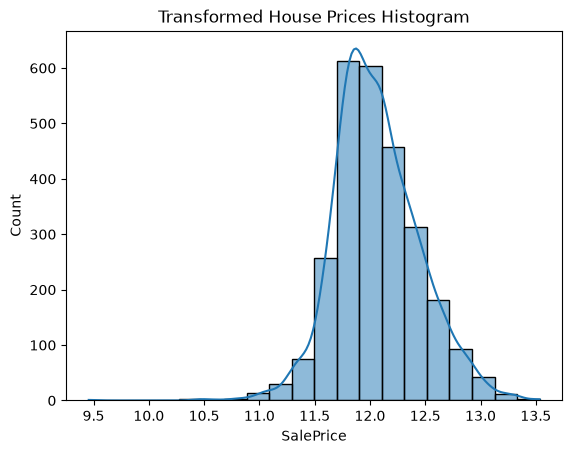

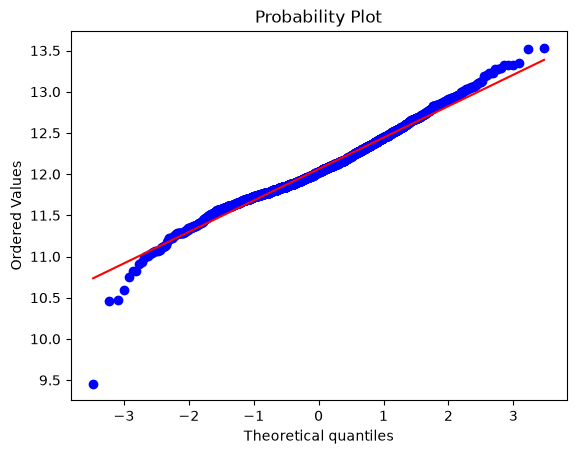

In [172]:
y_transformed = np.log1p(df['SalePrice'])
sns.histplot(y_transformed, bins=20, kde=True)
(mu, sigma) = norm.fit(y_transformed)
print(f'Distribution Mean: {mu}, Skew: {y_transformed.skew():.5} and Std Deviation: {sigma}')
plt.title('Transformed House Prices Histogram')
fig = plt.figure()
res = stats.probplot(y_transformed, plot=plt)
plt.show()

In [176]:
from sklearn.compose import TransformedTargetRegressor
rf = RandomForestRegressor()
log_rf = TransformedTargetRegressor(rf, func=np.log1p, inverse_func=np.expm1)
log_rf.fit(X_train_scaled, y_train)

y_train_pred_rf_transformed = log_rf.predict(X_train_scaled)
y_pred_rf_transformed = log_rf.predict(X_test_scaled)

mae_train_rf_transformed = mean_absolute_error(y_train, y_train_pred_rf_transformed)
mae_test_rf_transformed = mean_absolute_error(y_test, y_pred_rf_transformed)
mape_train_rf_transformed = mean_absolute_percentage_error(y_train, y_train_pred_rf_transformed) * 100
mape_test_rf_transformed = mean_absolute_percentage_error(y_test, y_pred_rf_transformed) * 100
rsme_train_rf_transformed = root_mean_squared_error(y_train, y_train_pred_rf_transformed)
rsme_test_rf_transformed = root_mean_squared_error(y_test, y_pred_rf_transformed)
r2_train_rf_transformed = r2_score(y_train, y_train_pred_rf_transformed)
r2_test_rf_transformed = r2_score(y_test, y_pred_rf_transformed)

print(f'MAE (training): {mae_train_rf_transformed}')
print(f'MAE (testing): {mae_test_rf_transformed}')
print(f'MAPE (training): {mape_train_rf_transformed:.4f}%')
print(f'MAPE (testing): {mape_test_rf_transformed:.4f}%')
print(f'RSME (training): {rsme_train_rf_transformed}')
print(f'RSME (testing): {rsme_test_rf_transformed}')
print(f'R-Squared score (training): {r2_train_rf_transformed}')
print(f'R-Squared score (testing): {r2_test_rf_transformed}')

MAE (training): 6601.46428469117
MAE (testing): 17812.576140560443
MAPE (training): 3.6586%
MAPE (testing): 10.0190%
RSME (training): 10230.88236783889
RSME (testing): 28024.1527958518
R-Squared score (training): 0.9837080525769969
R-Squared score (testing): 0.8675894345315946


In [178]:
rf = RandomForestRegressor(n_estimators=215,
                                     max_depth=9,
                                     max_features='sqrt',
                                     min_samples_leaf=1,
                                     min_samples_split=2,)
log_rf = TransformedTargetRegressor(rf, func=np.log1p, inverse_func=np.expm1)
log_rf.fit(X_train_scaled, y_train)

y_train_pred_rf_transformed = log_rf.predict(X_train_scaled)
y_pred_rf_transformed = log_rf.predict(X_test_scaled)

mae_train_rf_transformed = mean_absolute_error(y_train, y_train_pred_rf_transformed)
mae_test_rf_transformed = mean_absolute_error(y_test, y_pred_rf_transformed)
mape_train_rf_transformed = mean_absolute_percentage_error(y_train, y_train_pred_rf_transformed) * 100
mape_test_rf_transformed = mean_absolute_percentage_error(y_test, y_pred_rf_transformed) * 100
rsme_train_rf_transformed = root_mean_squared_error(y_train, y_train_pred_rf_transformed)
rsme_test_rf_transformed = root_mean_squared_error(y_test, y_pred_rf_transformed)
r2_train_rf_transformed = r2_score(y_train, y_train_pred_rf_transformed)
r2_test_rf_transformed = r2_score(y_test, y_pred_rf_transformed)

print(f'MAE (training): {mae_train_rf_transformed}')
print(f'MAE (testing): {mae_test_rf_transformed}')
print(f'MAPE (training): {mape_train_rf_transformed:.4f}%')
print(f'MAPE (testing): {mape_test_rf_transformed:.4f}%')
print(f'RSME (training): {rsme_train_rf_transformed}')
print(f'RSME (testing): {rsme_test_rf_transformed}')
print(f'R-Squared score (training): {r2_train_rf_transformed}')
print(f'R-Squared score (testing): {r2_test_rf_transformed}')

MAE (training): 11945.315308804455
MAE (testing): 16914.863035062855
MAPE (training): 6.6851%
MAPE (testing): 9.5201%
RSME (training): 17136.753138920598
RSME (testing): 26567.495094262562
R-Squared score (training): 0.9542907707235876
R-Squared score (testing): 0.8809967358280266


In [179]:
print(root_mean_squared_error(y_test, y_pred_rf_transformed))
df_y_pred_rf_transformed = pd.DataFrame(y_pred_rf_transformed, columns=['PredictedPrice'])
df_y_test = pd.DataFrame(y_test).reset_index(drop=True)
df_eval_t = pd.concat([df_y_pred_rf_transformed, df_y_test], axis=1)
df_eval_t['AbsoluteError'] = abs(df_eval_t['SalePrice'] - df_eval_t['PredictedPrice'])
df_eval_t.sort_values(by='AbsoluteError', ascending=False).head(10)

26567.495094262562


,PredictedPrice,SalePrice,AbsoluteError
473,359581.999463,150000.0,209581.999463
185,429141.927763,611657.0,182515.072237
32,261142.401449,375000.0,113857.598551
303,442774.340139,556581.0,113806.659861
238,200701.453935,311500.0,110798.546065
413,303741.867519,395000.0,91258.132481
379,250433.806766,335000.0,84566.193234
279,245513.704695,328000.0,82486.295305
155,453617.356027,535000.0,81382.643973
19,301990.087411,230000.0,71990.087411


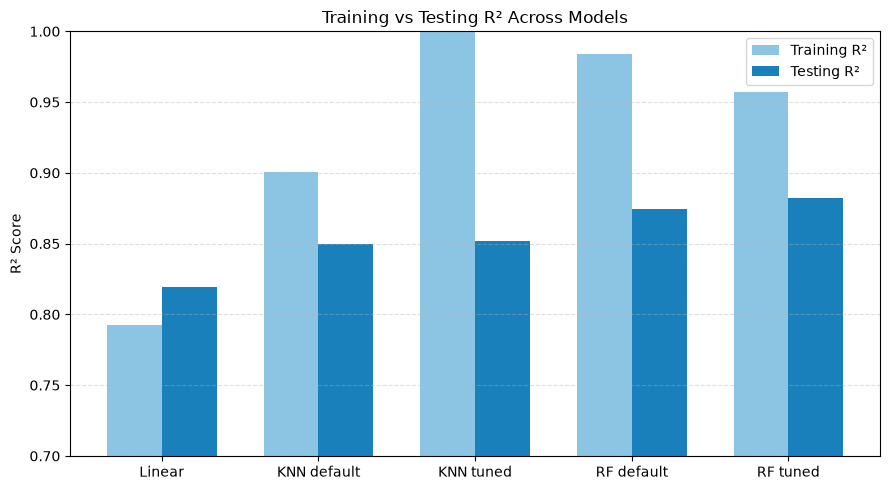

In [158]:
models = ['Linear', 'KNN default', 'KNN tuned', 'RF default', 'RF tuned']
train_r2 = [r2_train_lin, r2_train_knn_default, r2_train_knn_best, r2_train_rf_default, r2_train_rf_tuned]
test_r2 = [r2_test_lin, r2_test_knn_default, r2_test_knn_best, r2_test_rf_default, r2_test_rf_tuned]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, train_r2, width, label='Training R²', color='#8cc5e3')
ax.bar(x + width/2, test_r2, width, label='Testing R²', color='#1a80bb')
ax.set_ylabel('R² Score')
ax.set_title('Training vs Testing R² Across Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.70, 1.00)
plt.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [159]:
inflation_factor = 1.867

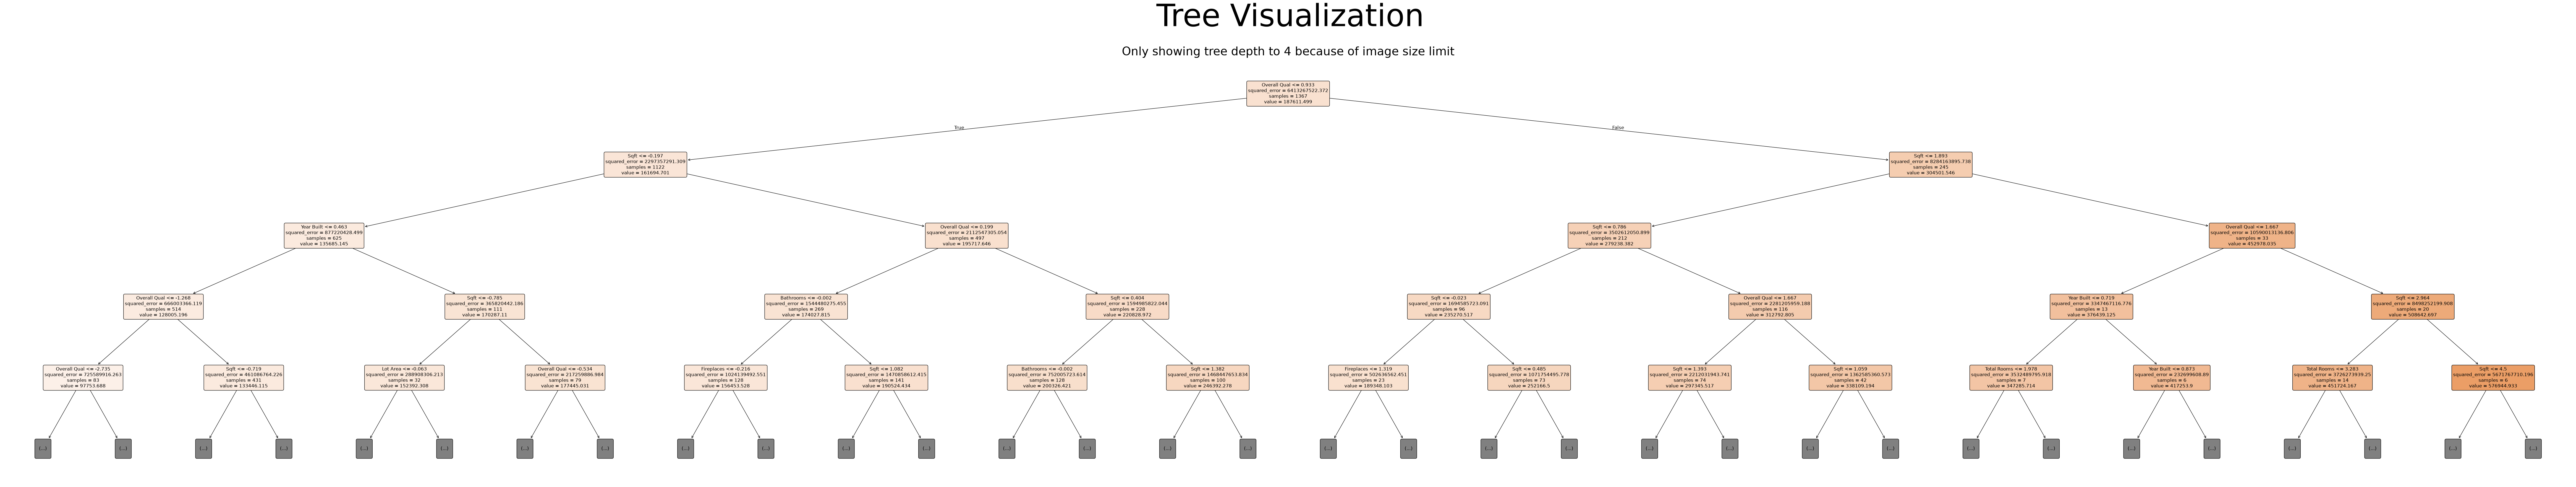

In [160]:
tree = rf_regressor.estimators_[0]
plt.figure(figsize=(120, 20))
plot_tree(tree,
          max_depth=4,
          feature_names=X_train.columns,
          filled=True,
          rounded=True,
          fontsize=12)
plt.suptitle('         Tree Visualization', fontsize=80)
plt.title('Only showing tree depth to 4 because of image size limit', fontsize=30)
plt.show()


In [161]:
import joblib

In [162]:
joblib.dump(rf_regressor_tuned, 'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
# joblib.dump(neighborhood_avg, 'neighborhood_avg.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_columns.pkl')

def predict_new_data(new_df):
    model = joblib.load('rf_model.pkl')
    scaler = joblib.load('scaler.pkl')
    # neighborhood_avg = joblib.load('neighborhood_avg.pkl')
    feature_columns = joblib.load('feature_columns.pkl')

    df = new_df.copy()

    # df['Neighborhood_encoded'] = df['Neighborhood'].map(neighborhood_avg)
    # df['Neighborhood_encoded'] = df['Neighborhood_encoded'].fillna(neighborhood_avg.mean())
    # df = df.drop(columns='Neighborhood')

    df = df[feature_columns]

    df_scaled = scaler.transform(df)

    return model.predict(df_scaled) * inflation_factor

In [163]:
X_train.columns

Index(['Overall Qual', 'Lot Area', 'Sqft', 'Has Basement', 'Garage Cars',
       'Year Built', 'Total Rooms', 'Bedrooms', 'Bathrooms', 'Fireplaces'],
      dtype='str')

In [164]:
new_data = pd.DataFrame({
    'Overall Qual': [np.nan],
    'Lot Area': [14209],
    'Sqft': [2875],
    'Has Basement': [1],
    'Garage Cars': [2],
    'Year Built': [2002],
    'Total Rooms': [18],
    'Bedrooms': [4],
    'Bathrooms': [4],
    'Fireplaces': [1],
})

prediction = predict_new_data(new_data)
print(f'Predicted price: {prediction.astype(int)}')

Predicted price: [409575]


In [165]:
new_data = pd.DataFrame({
    'Overall Qual': [np.nan],
    'Lot Area': [2405],
    'Sqft': [1748],
    'Has Basement': [1],
    'Garage Cars': [2],
    'Year Built': [2019],
    'Total Rooms': [14],
    'Bedrooms': [4],
    'Bathrooms': [4],
    'Fireplaces': [np.nan],
})

prediction = predict_new_data(new_data)
print(f'Predicted price: {prediction.astype(int)}')

Predicted price: [331104]


In [166]:
new_data = pd.DataFrame({
    'Overall Qual': [np.nan],
    'Lot Area': [216058],
    'Sqft': [5949],
    'Has Basement': [1],
    'Garage Cars': [3],
    'Year Built': [1996],
    'Total Rooms': [21],
    'Bedrooms': [8],
    'Bathrooms': [6],
    'Fireplaces': [2],
})

prediction = predict_new_data(new_data)
print(f'Predicted price: {prediction.astype(int)}')

Predicted price: [793951]
